# Predicción de Gravedad de Accidentes de Tránsito en Colombia
**Target:** `CON HERIDOS (0)` vs `CON MUERTOS (1)` — desbalanceo ~95/5  
**Métrica principal:** F1-Macro  
**Pipeline:** Limpieza → Feature Engineering (sin leakage) → Preprocesamiento → Modelado → Ranking

---
## Tabla de Contenidos
1. [Imports y Configuración](#1)
2. [Carga del Dataset](#2)
3. [Limpieza y Corrección de Tipos](#3)
4. [Feature Engineering (pre-split)](#4)
5. [Split Train / Test](#5)
6. [Feature Engineering (post-split, sin leakage)](#6)
7. [Preprocesador Final](#7)
8. [Función `evaluate_model`](#8)
9. [Modelos](#9)
   - 9.1 XGBoost
   - 9.2 Logistic Regression
   - 9.3 Random Forest
   - 9.4 LightGBM + SMOTE
   - 9.5 Balanced Random Forest
   - 9.6 Balanced Bagging + LightGBM
   - 9.7 Isolation Forest
   - 9.8 RUSBoost
   - 9.9 IMBoost
10. [Ranking Final de Modelos](#10)


## 1. Imports y Configuración Global <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import warnings
import time
import joblib
import os
import psutil
warnings.filterwarnings('ignore')
os.environ['LOKY_MAX_CPU_COUNT'] = str(psutil.cpu_count(logical=False))

plt.style.use('ggplot')
%matplotlib inline

# ── sklearn ───────────────────────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    RandomizedSearchCV, GridSearchCV, cross_validate
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, accuracy_score,
    f1_score, roc_curve, auc,
    precision_score, recall_score,
    average_precision_score, matthews_corrcoef,
    precision_recall_curve, balanced_accuracy_score,
    ConfusionMatrixDisplay, make_scorer
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_X_y, check_array

# ── imblearn ──────────────────────────────────────────────────────────────────
from imblearn.ensemble import (
    RUSBoostClassifier, BalancedRandomForestClassifier, BalancedBaggingClassifier
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ── otros ─────────────────────────────────────────────────────────────────────
import xgboost as xgb
import lightgbm as lgb
import lime
import lime.lime_tabular
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('✓ Imports OK')

✓ Imports OK


## 2. Carga del Dataset <a id='2'></a>

In [2]:
df = pd.read_csv(
    'VEHICULOS_INVOLUCRADOS_EN_UN_ACCIDENTE_DE_TRANSITO_LEY_2251-2022_20260205.csv',
    encoding='latin-1'
)
print(f'Dimensiones: {df.shape[0]:,} registros × {df.shape[1]} variables')
df.head()

Dimensiones: 406,540 registros × 9 variables


,MARCA_VEHICULO,MODELO_VEHICULO,TIPO_VEHICULO,EDAD_VEHICULO,FECHA_ACCIDENTE,GRAVEDAD_ACCIDENTE,DEPARTAMENTO_ACCIDENTE,MUNICIPIO_ACCIDENTE,AUTORIDAD_DE_TRANSITO
0,HONDA,2017,MOTOCICLETA,9.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
1,CHEVROLET,2007,CAMION,20.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
2,JEEP,2017,CAMPERO,9.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
3,CHEVROLET,2023,CAMIONETA,2.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
4,HONDA,2026,MOTOCICLETA,1.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA


## 3. Limpieza y Corrección de Tipos <a id='3'></a>

In [3]:
# Tipos
df['EDAD_VEHICULO']   = pd.to_numeric(df['EDAD_VEHICULO'],   errors='coerce')
df['MODELO_VEHICULO'] = pd.to_numeric(df['MODELO_VEHICULO'], errors='coerce')
df['FECHA_ACCIDENTE'] = pd.to_datetime('01/' + df['FECHA_ACCIDENTE'], format='%d/%m/%Y')

# Imputación: nulos en MARCA → 'Sin información'
df['MARCA_VEHICULO'] = df['MARCA_VEHICULO'].fillna('Sin información')

# Imputación EDAD_VEHICULO por mediana de TIPO_VEHICULO (evita sesgo global)
df['EDAD_VEHICULO'] = df.groupby('TIPO_VEHICULO')['EDAD_VEHICULO'].transform(
    lambda x: x.fillna(x.median())
)
df['EDAD_VEHICULO'] = df['EDAD_VEHICULO'].fillna(df['EDAD_VEHICULO'].median())

# Filtros de calidad
df = df[(df['MODELO_VEHICULO'] >= 1950) & (df['MODELO_VEHICULO'] <= 2025)]
df = df[df['EDAD_VEHICULO'] <= 60]

# Componentes temporales
df['AÑO']        = df['FECHA_ACCIDENTE'].dt.year
df['MES']        = df['FECHA_ACCIDENTE'].dt.month
df['DIA_SEMANA'] = df['FECHA_ACCIDENTE'].dt.day_name()

# Filtros temporales
df = df[df['AÑO'] <= 2025]

# Anomalía julio 2024 — STRIA DE TTOyTTE MEDELLIN (78.7% del volumen, tasa de
# mortalidad inversa al volumen: relación estadísticamente incompatible con fenómeno real)
mascara_anomalia = ~(
    (df['AÑO'] == 2024) & (df['MES'] == 7) &
    (df['AUTORIDAD_DE_TRANSITO'] == 'STRIA DE TTOyTTE MEDELLIN')
)
df = df[mascara_anomalia]
print(f'✓ Dataset final: {len(df):,} registros')
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().any() else '✓ Sin nulos')

✓ Dataset final: 378,470 registros
✓ Sin nulos


## 4. Feature Engineering (pre-split) <a id='4'></a>

> **Reglas anti-leakage:** solo se crean features que NO usen el target.  
> Todo lo que use `y_train` se calcula en la sección 6, después del split.

In [4]:
# Antigüedad y categoría de edad
df['ANTIGÜEDAD_VEHICULO'] = df['FECHA_ACCIDENTE'].dt.year - df['MODELO_VEHICULO']
bins_edad   = [0, 5, 10, 20, float('inf')]
labels_edad = ['0-5 años', '6-10 años', '11-20 años', '>20 años']
df['CAT_EDAD_VEHICULO'] = pd.cut(df['ANTIGÜEDAD_VEHICULO'], bins=bins_edad, labels=labels_edad)

# Temporales (sin target)
df['ES_VACACIONES']      = df['MES'].isin([1, 6, 7, 12]).astype(int)
df['ES_FIN_SEMANA']      = df['DIA_SEMANA'].isin(['Friday','Saturday','Sunday']).astype(int)
df['MES_SIN']            = np.sin(2 * np.pi * df['MES'] / 12)  # cíclico — evita ordinalidad falsa
df['MES_COS']            = np.cos(2 * np.pi * df['MES'] / 12)

# Vehículo
df['VEHICULO_MUY_ANTIGUO'] = (df['EDAD_VEHICULO'] > 30).astype(int)
df['EDAD_VEH_LOG']         = np.log1p(df['EDAD_VEHICULO'])

# Perfil de masa e interacción
def categorizar_perfil_fisico(tipo):
    tipo = str(tipo).strip().upper()
    if tipo in ['MOTOCICLETA','MOTOCARRO','CUATRIMOTO','CICLOMOTOR','CUADRICICLO']:
        return 'VULNERABLE'
    elif tipo in ['AUTOMOVIL','CAMIONETA','CAMPERO','MICROBUS']:
        return 'LIVIANO'
    elif tipo in ['CAMION','BUS','BUSETA','TRACTOCAMION','VOLQUETA','REMOLQUE','SEMIREMOLQUE']:
        return 'PESADO_RAPIDO'
    elif tipo in ['MONTACARGAS','TRACTOR','MAQ. AGRICOLA','MAQ. INDUSTRIAL',
                  'RETROEXCAVADORA','MOTONIVELADORA','MINICARGADOR','FRESADORA',
                  'COMPACTADOR','EXCAVADORA','CARGADOR','PAVIMENTADORA']:
        return 'MAQUINARIA_LENTA'
    else:
        return 'OTROS'

df['PERFIL_MASA']           = df['TIPO_VEHICULO'].apply(categorizar_perfil_fisico)
df['INTERACCION_MASA_EDAD'] = df['PERFIL_MASA'] + '_' + df['CAT_EDAD_VEHICULO'].astype(str)

print(f'✓ Features pre-split creadas. Shape: {df.shape}')

✓ Features pre-split creadas. Shape: (378470, 22)


In [5]:
dataset_clean = df.copy()
results       = []  # acumula resultados de todos los modelos

dataset_clean['Target'] = (dataset_clean['GRAVEDAD_ACCIDENTE'] == 'CON MUERTOS').astype(int)

columnas_base = [
    # Numéricas directas
    'EDAD_VEHICULO', 'EDAD_VEH_LOG', 'VEHICULO_MUY_ANTIGUO',
    'MES_SIN', 'MES_COS', 'ES_VACACIONES', 'ES_FIN_SEMANA',
    # Baja cardinalidad → OrdinalEncoder
    'DEPARTAMENTO_ACCIDENTE', 'PERFIL_MASA',
    # Alta cardinalidad → Target Encoding post-split
    'MUNICIPIO_ACCIDENTE', 'INTERACCION_MASA_EDAD',
    'MARCA_VEHICULO', 'AUTORIDAD_DE_TRANSITO',
]

X = dataset_clean[columnas_base].copy()
y = dataset_clean['Target'].copy()

print(f'Features: {X.shape[1]} | Registros: {len(X):,}')
print(f'CON MUERTOS: {y.sum():,} ({y.mean()*100:.2f}%)')

Features: 13 | Registros: 378,470
CON MUERTOS: 20,137 (5.32%)


## 5. Split Train / Test <a id='5'></a>

> **Muro de contención:** ningún cálculo que use `y_train` ocurre antes de esta celda.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

class_names = ['CON HERIDOS', 'CON MUERTOS']
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
ratio    = neg / pos

print(f'CON HERIDOS: {neg:,} ({neg/len(y_train)*100:.1f}%)')
print(f'CON MUERTOS: {pos:,} ({pos/len(y_train)*100:.1f}%)')
print(f'Ratio: {ratio:.1f} | Train: {len(X_train):,} | Test: {len(X_test):,}')

CON HERIDOS: 286,666 (94.7%)
CON MUERTOS: 16,110 (5.3%)
Ratio: 17.8 | Train: 302,776 | Test: 75,694


## 6. Feature Engineering post-split (sin leakage) <a id='6'></a>

Todas las features que usan `y_train` se calculan aquí, solo sobre train, y se mapean al test sin acceder a `y_test`.

In [7]:
X_train = X_train.copy()
X_test  = X_test.copy()

def target_encode(col_train, col_test, y_tr, smooth=50):
    """Target encoding con suavizado bayesiano. Fit solo sobre train — sin leakage."""
    global_mean = y_tr.mean()
    stats = pd.DataFrame({'y': y_tr.values, 'col': col_train.values})
    agg   = stats.groupby('col')['y'].agg(['mean', 'count'])
    agg['te'] = (agg['count'] * agg['mean'] + smooth * global_mean) / (agg['count'] + smooth)
    return (col_train.map(agg['te']).fillna(global_mean),
            col_test.map(agg['te']).fillna(global_mean))

# 6.1 Municipio → tasa histórica P(muerte|municipio)
X_train['TASA_MORT_MUNICIPIO'], X_test['TASA_MORT_MUNICIPIO'] = target_encode(
    X_train['MUNICIPIO_ACCIDENTE'], X_test['MUNICIPIO_ACCIDENTE'], y_train)

# 6.2 Frecuencia por municipio (no usa target)
freq_mun = X_train['MUNICIPIO_ACCIDENTE'].value_counts(normalize=True)
freq_fallback = freq_mun.mean()
X_train['FREQ_MUNICIPIO'] = X_train['MUNICIPIO_ACCIDENTE'].map(freq_mun).fillna(freq_fallback)
X_test['FREQ_MUNICIPIO']  = X_test['MUNICIPIO_ACCIDENTE'].map(freq_mun).fillna(freq_fallback)

# 6.3 Interacción masa × edad
X_train['INTERACCION_TE'], X_test['INTERACCION_TE'] = target_encode(
    X_train['INTERACCION_MASA_EDAD'], X_test['INTERACCION_MASA_EDAD'], y_train)

# 6.4 Marca de vehículo → P(muerte|marca)
X_train['TASA_MORT_MARCA'], X_test['TASA_MORT_MARCA'] = target_encode(
    X_train['MARCA_VEHICULO'], X_test['MARCA_VEHICULO'], y_train)

# 6.5 Autoridad de tránsito → P(muerte|autoridad) — refleja tipo de vía implícitamente
X_train['TASA_MORT_AUTORIDAD'], X_test['TASA_MORT_AUTORIDAD'] = target_encode(
    X_train['AUTORIDAD_DE_TRANSITO'], X_test['AUTORIDAD_DE_TRANSITO'], y_train)

# Eliminar columnas de alta cardinalidad ya representadas por TE
cols_drop = ['MUNICIPIO_ACCIDENTE', 'INTERACCION_MASA_EDAD', 'MARCA_VEHICULO', 'AUTORIDAD_DE_TRANSITO']
X_train = X_train.drop(columns=[c for c in cols_drop if c in X_train.columns])
X_test  = X_test.drop(columns=[c for c in cols_drop if c in X_test.columns])

print(f'✓ Features post-split. Shape train: {X_train.shape} | test: {X_test.shape}')

✓ Features post-split. Shape train: (302776, 14) | test: (75694, 14)


## 7. Preprocesador Final <a id='7'></a>

`OrdinalEncoder` para categóricas (no OHE) — los tree-based models manejan bien ordinales y evitamos explosión de dimensionalidad.

In [8]:
numeric_features = [
    'EDAD_VEHICULO', 'EDAD_VEH_LOG', 'VEHICULO_MUY_ANTIGUO',
    'MES_SIN', 'MES_COS', 'ES_VACACIONES', 'ES_FIN_SEMANA',
    'TASA_MORT_MUNICIPIO', 'FREQ_MUNICIPIO', 'INTERACCION_TE',
    'TASA_MORT_MARCA', 'TASA_MORT_AUTORIDAD',
]
categorical_features = ['DEPARTAMENTO_ACCIDENTE', 'PERFIL_MASA']

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ]), categorical_features),
], remainder='drop')

print(f'✓ Preprocesador definido')
print(f'  Numéricas  ({len(numeric_features)}): {numeric_features}')
print(f'  Categóricas ({len(categorical_features)}): {categorical_features}')
print(f'  Total features al modelo: {len(numeric_features) + len(categorical_features)}')

✓ Preprocesador definido
  Numéricas  (12): ['EDAD_VEHICULO', 'EDAD_VEH_LOG', 'VEHICULO_MUY_ANTIGUO', 'MES_SIN', 'MES_COS', 'ES_VACACIONES', 'ES_FIN_SEMANA', 'TASA_MORT_MUNICIPIO', 'FREQ_MUNICIPIO', 'INTERACCION_TE', 'TASA_MORT_MARCA', 'TASA_MORT_AUTORIDAD']
  Categóricas (2): ['DEPARTAMENTO_ACCIDENTE', 'PERFIL_MASA']
  Total features al modelo: 14


## 8. Función `evaluate_model` <a id='8'></a>

Función unificada para todos los modelos. Produce **las mismas 3 gráficas** siempre: ROC, Precision-Recall y Matriz de Confusión.

In [9]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name,
                   cv_folds=5, make_plots=True, refit=True):
    """
    Evalúa un modelo. Métrica principal: F1-Macro.
    refit=False → no re-entrena (para best_estimator_ de GridSearch/RandomizedSearch).
    """
    results_cv = {}

    # ── Validación cruzada ────────────────────────────────────────────────────
    if cv_folds > 0:
        print(f"\n{'='*60}")
        print(f"VALIDACIÓN CRUZADA ({cv_folds} folds) — {model_name}")
        print(f"{'='*60}")
        cv      = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
        scoring = {
            'accuracy': 'accuracy', 'f1_macro': 'f1_macro',
            'f1_weighted': 'f1_weighted',
            'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro',
        }
        if hasattr(model, 'predict_proba'):
            scoring['roc_auc'] = make_scorer(roc_auc_score, needs_proba=True,
                                             multi_class='ovr', average='weighted')
        cv_res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring,
                                n_jobs=-1, return_train_score=True)
        results_cv = {
            'cv_accuracy_mean':       cv_res['test_accuracy'].mean(),
            'cv_accuracy_std':        cv_res['test_accuracy'].std(),
            'cv_f1_macro_mean':       cv_res['test_f1_macro'].mean(),
            'cv_f1_macro_std':        cv_res['test_f1_macro'].std(),
            'cv_f1_weighted_mean':    cv_res['test_f1_weighted'].mean(),
            'cv_f1_weighted_std':     cv_res['test_f1_weighted'].std(),
            'cv_train_f1_macro_mean': cv_res['train_f1_macro'].mean(),
            'cv_train_accuracy_mean': cv_res['train_accuracy'].mean(),
        }
        if 'test_roc_auc' in cv_res:
            results_cv['cv_auc_mean'] = cv_res['test_roc_auc'].mean()
            results_cv['cv_auc_std']  = cv_res['test_roc_auc'].std()

        print(f"   F1-Macro (CV):    {results_cv['cv_f1_macro_mean']:.4f} ± {results_cv['cv_f1_macro_std']:.4f}  ← PRINCIPAL")
        print(f"   Accuracy (CV):    {results_cv['cv_accuracy_mean']:.4f} ± {results_cv['cv_accuracy_std']:.4f}")
        print(f"   F1-Weighted (CV): {results_cv['cv_f1_weighted_mean']:.4f} ± {results_cv['cv_f1_weighted_std']:.4f}")
        if 'cv_auc_mean' in results_cv:
            print(f"   AUC (CV):         {results_cv['cv_auc_mean']:.4f} ± {results_cv['cv_auc_std']:.4f}")

        gap = results_cv['cv_train_f1_macro_mean'] - results_cv['cv_f1_macro_mean']
        print(f"\n   Gap Train-Val F1-Macro: {gap:.4f}",
              '⚠ Posible overfitting' if gap > 0.05 else '✓ Sin overfitting aparente')

    # ── Evaluación en test ────────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print(f"TEST SET — {model_name}")
    print(f"{'='*60}")

    t0 = time.time()
    if refit:
        model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred       = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None

    accuracy        = accuracy_score(y_test, y_pred)
    f1_macro        = f1_score(y_test, y_pred, average='macro',    zero_division=0)
    f1_weighted     = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall_macro    = recall_score(y_test, y_pred,    average='macro', zero_division=0)
    f1_muertos      = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec_muertos     = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    pre_muertos     = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    mcc             = matthews_corrcoef(y_test, y_pred)

    auc_score = aucpr = None
    if y_pred_proba is not None and len(np.unique(y_test)) > 1:
        try:
            auc_score = roc_auc_score(y_test, y_pred_proba[:, 1])
            aucpr     = average_precision_score(y_test, y_pred_proba[:, 1])
        except Exception as e:
            print(f'⚠ AUC error: {e}')

    print(f"   F1-Macro:          {f1_macro:.4f}  ← PRINCIPAL")
    print(f"   F1-MUERTOS:        {f1_muertos:.4f}")
    print(f"   Recall-MUERTOS:    {rec_muertos:.4f}")
    print(f"   Precision-MUERTOS: {pre_muertos:.4f}")
    print(f"   Accuracy:          {accuracy:.4f}")
    print(f"   MCC:               {mcc:.4f}")
    if auc_score: print(f"   ROC-AUC:           {auc_score:.4f}")
    if aucpr:     print(f"   PR-AUC:            {aucpr:.4f}")
    print(f"   Tiempo:            {train_time:.2f}s")
    print()
    print(classification_report(y_test, y_pred, target_names=class_names))

    # ── Gráficas estándar (iguales para TODOS los modelos) ────────────────────
    if make_plots:
        fig, axes = plt.subplots(1, 3, figsize=(19, 5))
        fig.suptitle(f'Evaluación: {model_name}', fontsize=13, fontweight='bold')

        # 1. ROC
        if y_pred_proba is not None:
            fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])
            axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC={auc(fpr,tpr):.3f}')
            axes[0].plot([0,1],[0,1], 'navy', lw=2, linestyle='--', label='Baseline')
            axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
            axes[0].set_title('Curva ROC'); axes[0].legend(); axes[0].grid(alpha=0.3)

        # 2. Precision-Recall
        if y_pred_proba is not None:
            prec_c, rec_c, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])
            ap = average_precision_score(y_test, y_pred_proba[:, 1])
            axes[1].plot(rec_c, prec_c, color='green', lw=2, label=f'PR-AUC={ap:.3f}')
            axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--', label='Baseline')
            axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
            axes[1].set_title('Curva Precision-Recall'); axes[1].legend(); axes[1].grid(alpha=0.3)

        # 3. Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
                    xticklabels=class_names, yticklabels=class_names)
        axes[2].set_title('Matriz de Confusión')
        axes[2].set_xlabel('Predicción'); axes[2].set_ylabel('Real')

        plt.tight_layout(); plt.show()

    result = {
        'model': model_name, 'accuracy': accuracy,
        'f1_macro': f1_macro, 'f1_weighted': f1_weighted,
        'f1_muertos': f1_muertos, 'recall_muertos': rec_muertos,
        'precision_macro': precision_macro, 'recall_macro': recall_macro,
        'mcc': mcc, 'auc': auc_score, 'pr_auc': aucpr,
        'train_time': train_time, 'predictions': y_pred,
        'probabilities': y_pred_proba,
        'f1': f1_macro, 'precision': precision_macro, 'recall': recall_macro,
    }
    if results_cv:
        result.update(results_cv)
    return result

print('✓ evaluate_model definida')

✓ evaluate_model definida


## 9. Modelos <a id='9'></a>

Cada modelo sigue el mismo patrón:
1. Definición del pipeline
2. Búsqueda de hiperparámetros (RandomizedSearch / GridSearch)
3. Threshold tuning sobre validación interna (sin tocar X_test)
4. `evaluate_model` → gráficas estándar
5. `results.append(result)`

### 9.1 XGBoost <a id='9.1'></a>

[XGBoost] RandomizedSearch 20 iter × 5 folds...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores params: {'model__subsample': 0.8, 'model__scale_pos_weight': 8.897144630664183, 'model__n_estimators': 300, 'model__min_child_weight': 5, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.7}
F1-Macro (CV):  0.6318

VALIDACIÓN CRUZADA (5 folds) — XGBoost
   F1-Macro (CV):    0.6318 ± 0.0011  ← PRINCIPAL
   Accuracy (CV):    0.8739 ± 0.0013
   F1-Weighted (CV): 0.8986 ± 0.0008
   AUC (CV):         0.8322 ± 0.0018

   Gap Train-Val F1-Macro: 0.0136 ✓ Sin overfitting aparente

TEST SET — XGBoost
   F1-Macro:          0.6262  ← PRINCIPAL
   F1-MUERTOS:        0.3235
   Recall-MUERTOS:    0.5783
   Precision-MUERTOS: 0.2246
   Accuracy:          0.8713
   MCC:               0.3042
   ROC-AUC:           0.8251
   PR-AUC:            0.2600
   Tiempo:            0.00s

              precision    recall  f1-score   support

 CON HERIDOS       0.97  

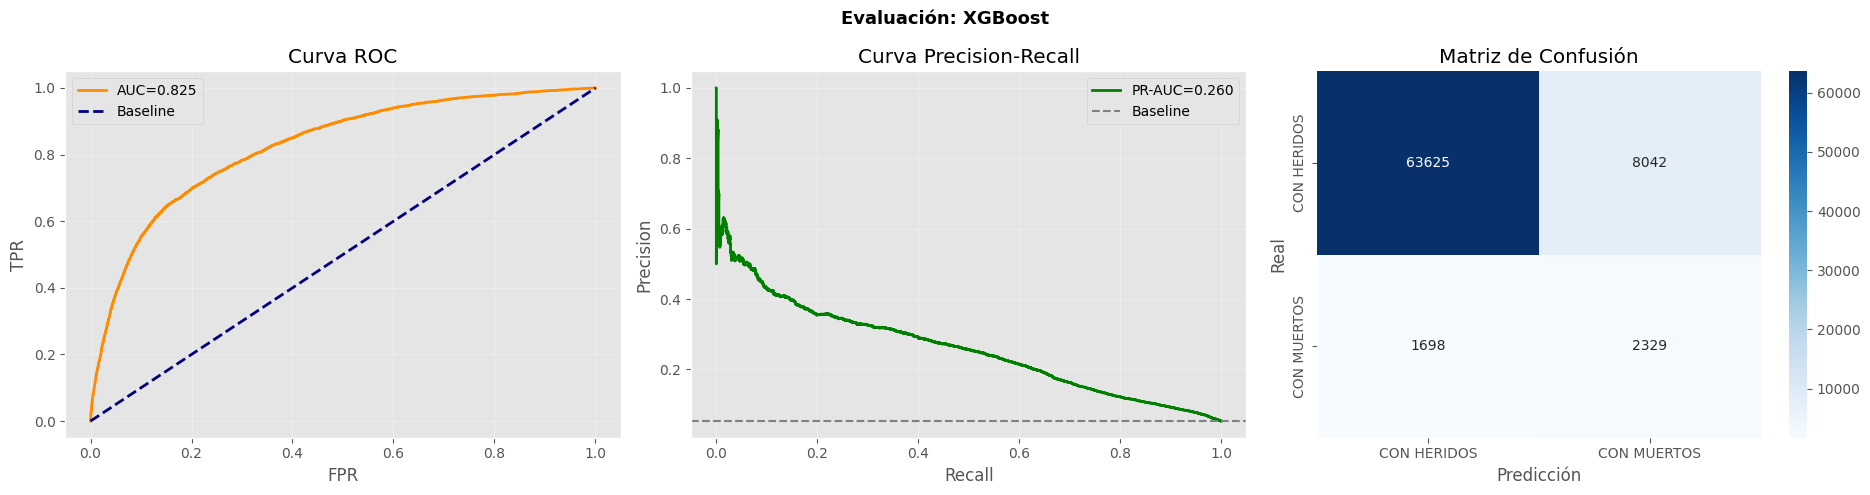

In [10]:
# ── Pipeline ──────────────────────────────────────────────────────────────────
pipe_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb.XGBClassifier(
        random_state=RANDOM_STATE, eval_metric='aucpr',
        scale_pos_weight=ratio, max_delta_step=1,
        device='cuda', tree_method='hist', nthread=-1
    ))
])

param_grid_xgb = {
    'model__n_estimators':     [200, 300, 400],
    'model__max_depth':        [3, 5],
    'model__learning_rate':    [0.05, 0.1],
    'model__subsample':        [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.7, 0.8, 0.9],
    'model__min_child_weight': [1, 5, 10],
    'model__scale_pos_weight': [ratio * 0.5, ratio, ratio * 1.5],
}

print('[XGBoost] RandomizedSearch 20 iter × 5 folds...')
rs_xgb = RandomizedSearchCV(
    pipe_xgb, param_grid_xgb, n_iter=20,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring=make_scorer(f1_score, average='macro'), n_jobs=1,
    random_state=RANDOM_STATE, verbose=1
)
rs_xgb.fit(X_train, y_train)
print(f'Mejores params: {rs_xgb.best_params_}')
print(f'F1-Macro (CV):  {rs_xgb.best_score_:.4f}')

result_xgb = evaluate_model(
    rs_xgb.best_estimator_, X_train, X_test, y_train, y_test,
    model_name='XGBoost', cv_folds=5, make_plots=True, refit=False
)
results.append(result_xgb)

### 9.2 Logistic Regression <a id='9.2'></a>

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Mejores params: {'model__C': 10, 'model__penalty': 'l1'}
F1-Macro (CV):  0.5987

VALIDACIÓN CRUZADA (5 folds) — Logistic Regression
   F1-Macro (CV):    0.5987 ± 0.0009  ← PRINCIPAL
   Accuracy (CV):    0.8283 ± 0.0017
   F1-Weighted (CV): 0.8699 ± 0.0011
   AUC (CV):         0.8250 ± 0.0012

   Gap Train-Val F1-Macro: -0.0000 ✓ Sin overfitting aparente

TEST SET — Logistic Regression
   F1-Macro:          0.5961  ← PRINCIPAL
   F1-MUERTOS:        0.2903
   Recall-MUERTOS:    0.6633
   Precision-MUERTOS: 0.1858
   Accuracy:          0.8275
   MCC:               0.2861
   ROC-AUC:           0.8190
   PR-AUC:            0.2410
   Tiempo:            0.00s

              precision    recall  f1-score   support

 CON HERIDOS       0.98      0.84      0.90     71667
 CON MUERTOS       0.19      0.66      0.29      4027

    accuracy                           0.83     75694
   macro avg       0.58      0.75      0.60     75694
weight

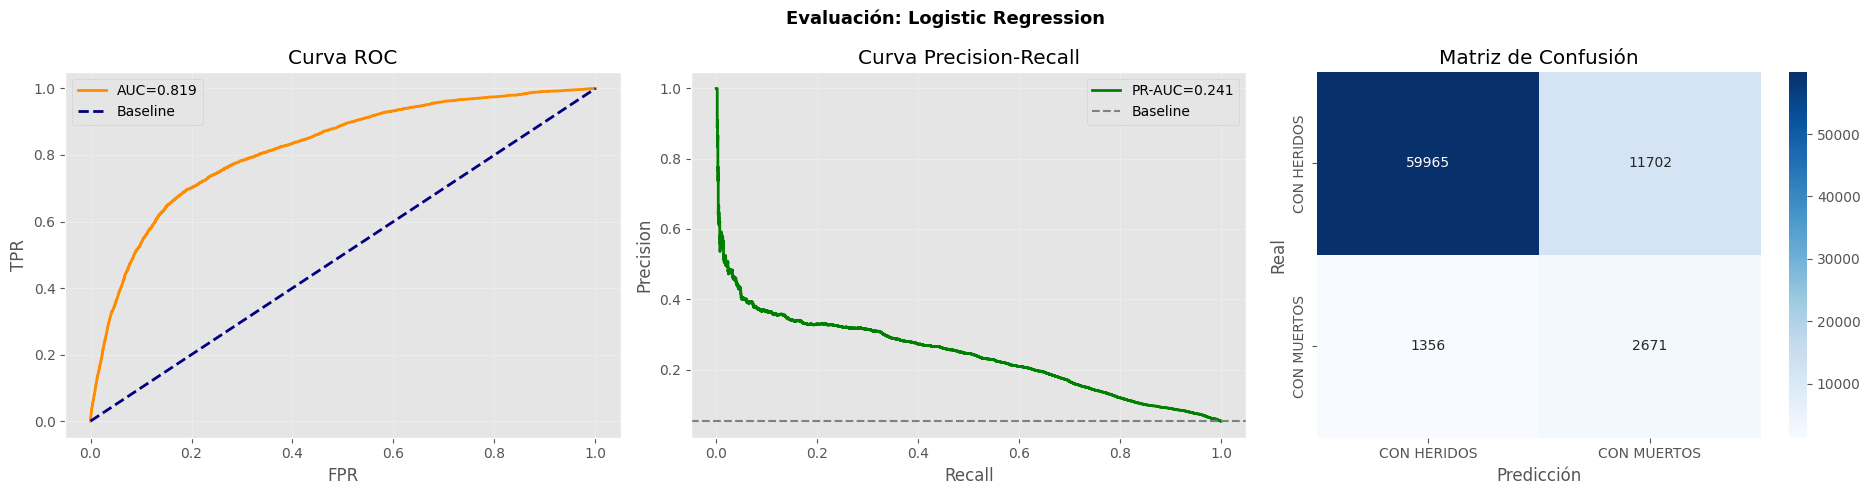

In [11]:
pipe_logreg = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                  class_weight='balanced', solver='liblinear'))
])

gs_logreg = GridSearchCV(
    pipe_logreg, {'model__C': [0.01, 0.1, 1, 10], 'model__penalty': ['l1', 'l2']},
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro', n_jobs=-1, verbose=1
)
gs_logreg.fit(X_train, y_train)
print(f'Mejores params: {gs_logreg.best_params_}')
print(f'F1-Macro (CV):  {gs_logreg.best_score_:.4f}')

result_lr = evaluate_model(
    gs_logreg.best_estimator_, X_train, X_test, y_train, y_test,
    model_name='Logistic Regression', cv_folds=5, make_plots=True, refit=False
)
results.append(result_lr)

### 9.3 Random Forest <a id='9.3'></a>

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores params: {'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 200}
F1-Macro (CV):  0.6274

VALIDACIÓN CRUZADA (5 folds) — Random Forest
   F1-Macro (CV):    0.6274 ± 0.0021  ← PRINCIPAL
   Accuracy (CV):    0.9124 ± 0.0010
   F1-Weighted (CV): 0.9186 ± 0.0005
   AUC (CV):         0.7960 ± 0.0019

   Gap Train-Val F1-Macro: 0.1914 ⚠ Posible overfitting

TEST SET — Random Forest
   F1-Macro:          0.6244  ← PRINCIPAL
   F1-MUERTOS:        0.2980
   Recall-MUERTOS:    0.3673
   Precision-MUERTOS: 0.2507
   Accuracy:          0.9079
   MCC:               0.2559
   ROC-AUC:           0.7894
   PR-AUC:            0.2110
   Tiempo:            0.00s

              precision    recall  f1-score   support

 CON HERIDOS       0.96      0.94      0.95     71667
 CON MUERTOS       0.25      0.37      0.30      4027

    accuracy                           0.91     75694
   macro avg       0.61      0.65 

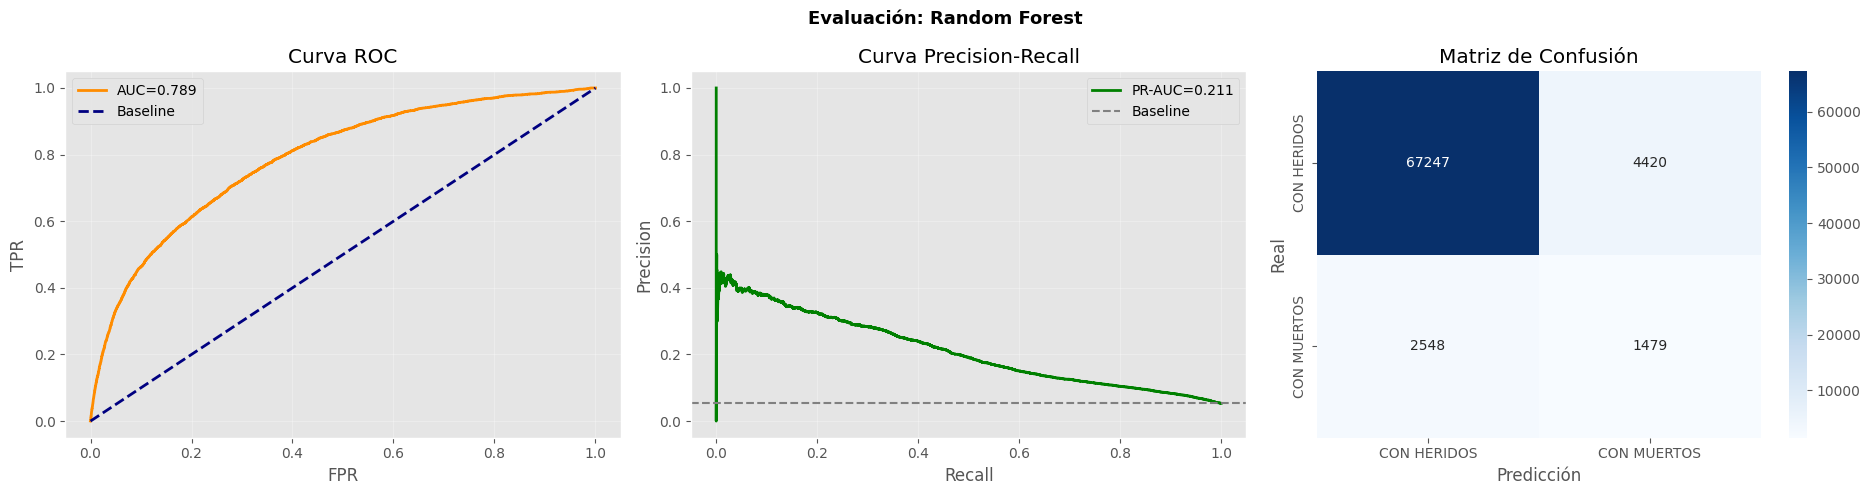

In [12]:
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                                      class_weight='balanced'))
])

gs_rf = GridSearchCV(
    pipe_rf,
    {'model__n_estimators': [100, 200], 'model__max_depth': [None, 10, 20],
     'model__min_samples_split': [2, 5]},
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro', n_jobs=-1, verbose=1
)
gs_rf.fit(X_train, y_train)
print(f'Mejores params: {gs_rf.best_params_}')
print(f'F1-Macro (CV):  {gs_rf.best_score_:.4f}')

result_rf = evaluate_model(
    gs_rf.best_estimator_, X_train, X_test, y_train, y_test,
    model_name='Random Forest', cv_folds=5, make_plots=True, refit=False
)
results.append(result_rf)

### 9.4 LightGBM + SMOTE <a id='9.4'></a>

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Mejores params: {'smote__sampling_strategy': 0.4, 'model__subsample': 0.9, 'model__num_leaves': 127, 'model__n_estimators': 500, 'model__max_depth': 8, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.7}
F1-Macro (CV):  0.5634

TEST SET — LightGBM + SMOTE
   F1-Macro:          0.5518  ← PRINCIPAL
   F1-MUERTOS:        0.1321
   Recall-MUERTOS:    0.0790
   Precision-MUERTOS: 0.4030
   Accuracy:          0.9448
   MCC:               0.1600
   ROC-AUC:           0.8034
   PR-AUC:            0.2287
   Tiempo:            0.00s

              precision    recall  f1-score   support

 CON HERIDOS       0.95      0.99      0.97     71667
 CON MUERTOS       0.40      0.08      0.13      4027

    accuracy                           0.94     75694
   macro avg       0.68      0.54      0.55     75694
weighted avg       0.92      0.94      0.93     75694



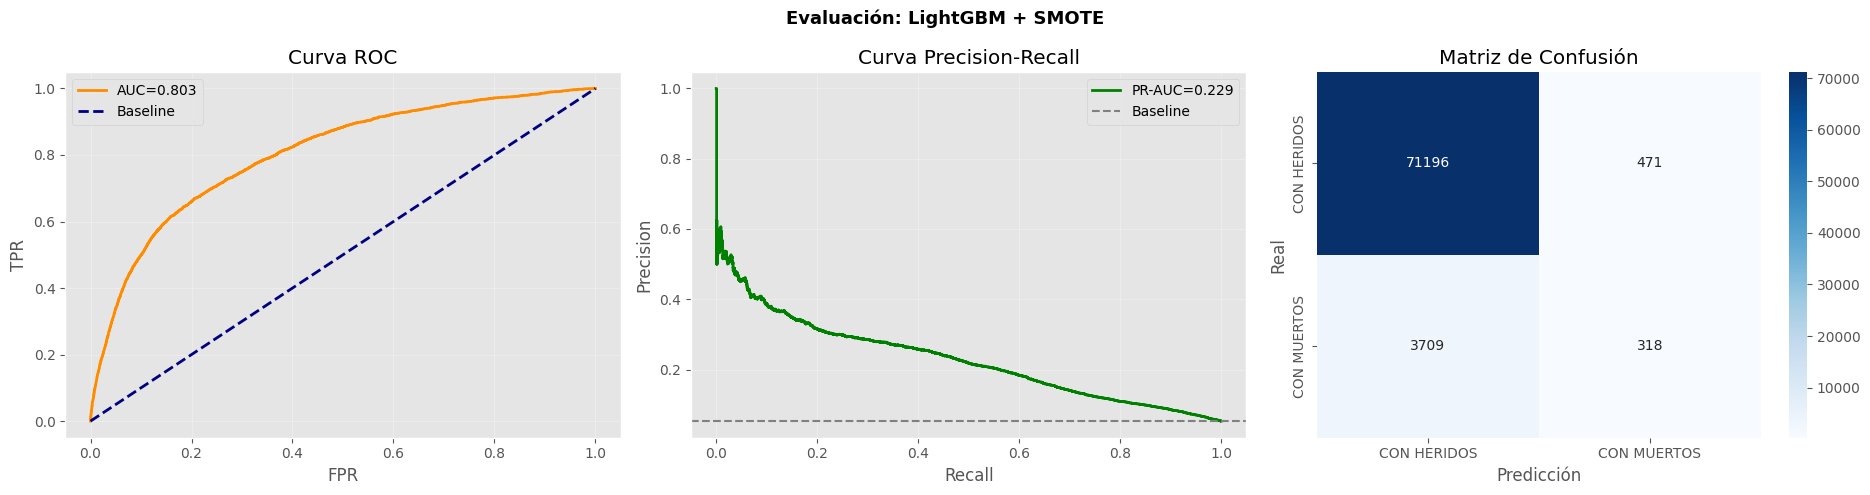

In [13]:
# Submuestra 60% para viabilidad temporal con 400k registros
X_tr_sub_lgbm, _, y_tr_sub_lgbm, _ = train_test_split(
    X_train, y_train, test_size=0.40, random_state=RANDOM_STATE, stratify=y_train
)
X_tr_cv_lgbm, X_val_lgbm, y_tr_cv_lgbm, y_val_lgbm = train_test_split(
    X_tr_sub_lgbm, y_tr_sub_lgbm, test_size=0.20,
    random_state=RANDOM_STATE, stratify=y_tr_sub_lgbm
)

pipe_lgbm = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(sampling_strategy=0.3, random_state=RANDOM_STATE, n_jobs=1)),
    ('model', lgb.LGBMClassifier(random_state=RANDOM_STATE, device='gpu',
                                   verbose=-1, n_jobs=1, min_child_samples=20))
])

param_grid_lgbm = {
    'model__n_estimators':     [300, 500, 700],
    'model__max_depth':        [6, 8, -1],
    'model__learning_rate':    [0.03, 0.05, 0.1],
    'model__num_leaves':       [63, 127],
    'model__subsample':        [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.7, 0.8, 0.9],
    'smote__sampling_strategy': [0.2, 0.3, 0.4],
}

rs_lgbm = RandomizedSearchCV(
    pipe_lgbm, param_grid_lgbm, n_iter=20,
    cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
    scoring=make_scorer(f1_score, average='macro'), n_jobs=-1,
    random_state=RANDOM_STATE, verbose=1, refit=True
)
rs_lgbm.fit(X_tr_cv_lgbm, y_tr_cv_lgbm)
print(f'Mejores params: {rs_lgbm.best_params_}')
print(f'F1-Macro (CV):  {rs_lgbm.best_score_:.4f}')

result_lgbm = evaluate_model(
    rs_lgbm.best_estimator_, X_tr_cv_lgbm, X_test, y_tr_cv_lgbm, y_test,
    model_name='LightGBM + SMOTE', cv_folds=0, make_plots=True, refit=False
)
results.append(result_lgbm)

### 9.5 Balanced Random Forest <a id='9.5'></a>

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Mejores params: {'model__sampling_strategy': 0.3, 'model__n_estimators': 300, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 10}
F1-Macro (CV):  0.6440

TEST SET — Balanced Random Forest
   F1-Macro:          0.6405  ← PRINCIPAL
   F1-MUERTOS:        0.3365
   Recall-MUERTOS:    0.4889
   Precision-MUERTOS: 0.2565
   Accuracy:          0.8974
   MCC:               0.3043
   ROC-AUC:           0.8269
   PR-AUC:            0.2490
   Tiempo:            0.00s

              precision    recall  f1-score   support

 CON HERIDOS       0.97      0.92      0.94     71667
 CON MUERTOS       0.26      0.49      0.34      4027

    accuracy                           0.90     75694
   macro avg       0.61      0.70      0.64     75694
weighted avg       0.93      0.90      0.91     75694



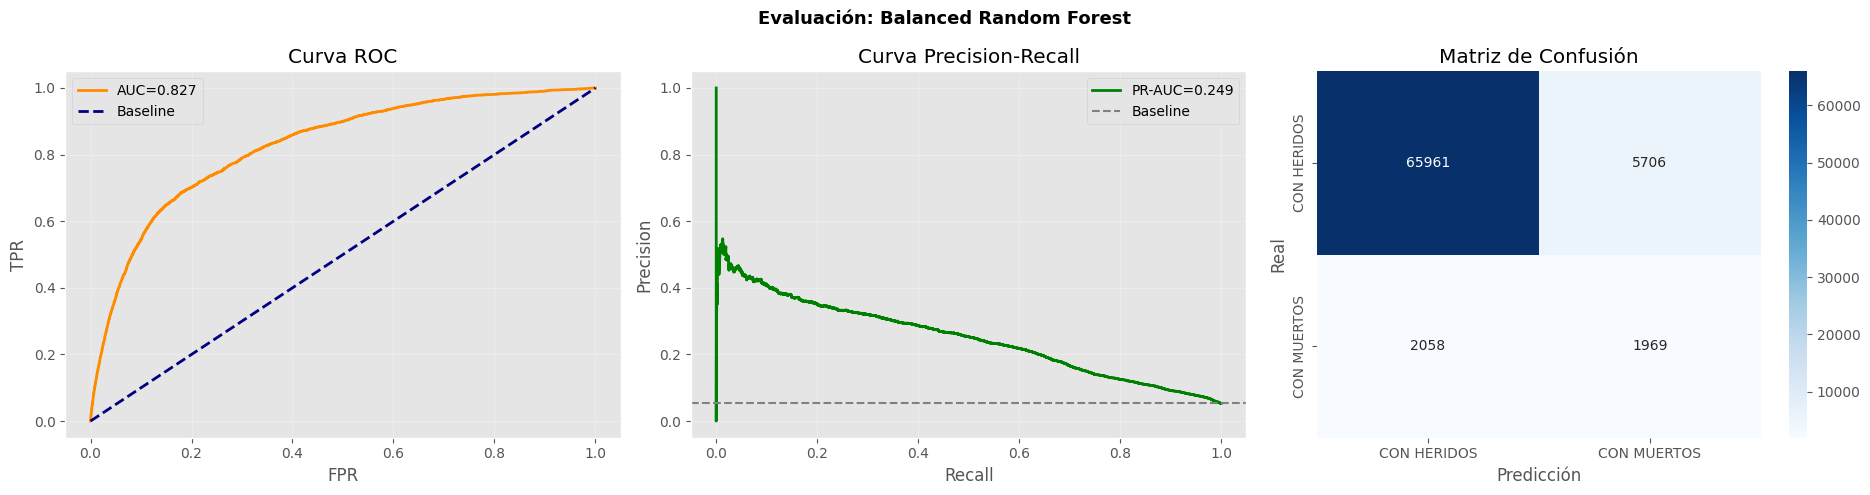

In [14]:
X_tr_sub_brf, _, y_tr_sub_brf, _ = train_test_split(
    X_train, y_train, test_size=0.40, random_state=RANDOM_STATE, stratify=y_train
)
X_tr_cv_brf, X_val_brf, y_tr_cv_brf, y_val_brf = train_test_split(
    X_tr_sub_brf, y_tr_sub_brf, test_size=0.20,
    random_state=RANDOM_STATE, stratify=y_tr_sub_brf
)

pipe_brf = ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', BalancedRandomForestClassifier(
        random_state=RANDOM_STATE, replacement=True, n_jobs=-1, verbose=0
    ))
])

rs_brf = RandomizedSearchCV(
    pipe_brf,
    {'model__n_estimators': [200, 300, 400], 'model__max_depth': [5, 10, 15, None],
     'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, 4],
     'model__sampling_strategy': ['auto', 0.3, 0.5, 0.75]},
    n_iter=20, cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
    scoring=make_scorer(f1_score, average='macro'), n_jobs=1,
    random_state=RANDOM_STATE, verbose=1
)
rs_brf.fit(X_tr_cv_brf, y_tr_cv_brf)
print(f'Mejores params: {rs_brf.best_params_}')
print(f'F1-Macro (CV):  {rs_brf.best_score_:.4f}')

result_brf = evaluate_model(
    rs_brf.best_estimator_, X_tr_cv_brf, X_test, y_tr_cv_brf, y_test,
    model_name='Balanced Random Forest', cv_folds=0, make_plots=True, refit=False
)
results.append(result_brf)

### 9.6 Balanced Bagging + LightGBM <a id='9.6'></a>

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Mejores params: {'model__sampling_strategy': 0.5, 'model__replacement': False, 'model__n_estimators': 30, 'model__estimator__subsample': 0.8, 'model__estimator__num_leaves': 63, 'model__estimator__max_depth': 7}
F1-Macro (CV):  0.6307

TEST SET — Balanced Bagging + LightGBM
   F1-Macro:          0.6251  ← PRINCIPAL
   F1-MUERTOS:        0.3216
   Recall-MUERTOS:    0.5764
   Precision-MUERTOS: 0.2230
   Accuracy:          0.8707
   MCC:               0.3021
   ROC-AUC:           0.8250
   PR-AUC:            0.2539
   Tiempo:            0.00s

              precision    recall  f1-score   support

 CON HERIDOS       0.97      0.89      0.93     71667
 CON MUERTOS       0.22      0.58      0.32      4027

    accuracy                           0.87     75694
   macro avg       0.60      0.73      0.63     75694
weighted avg       0.93      0.87      0.90     75694



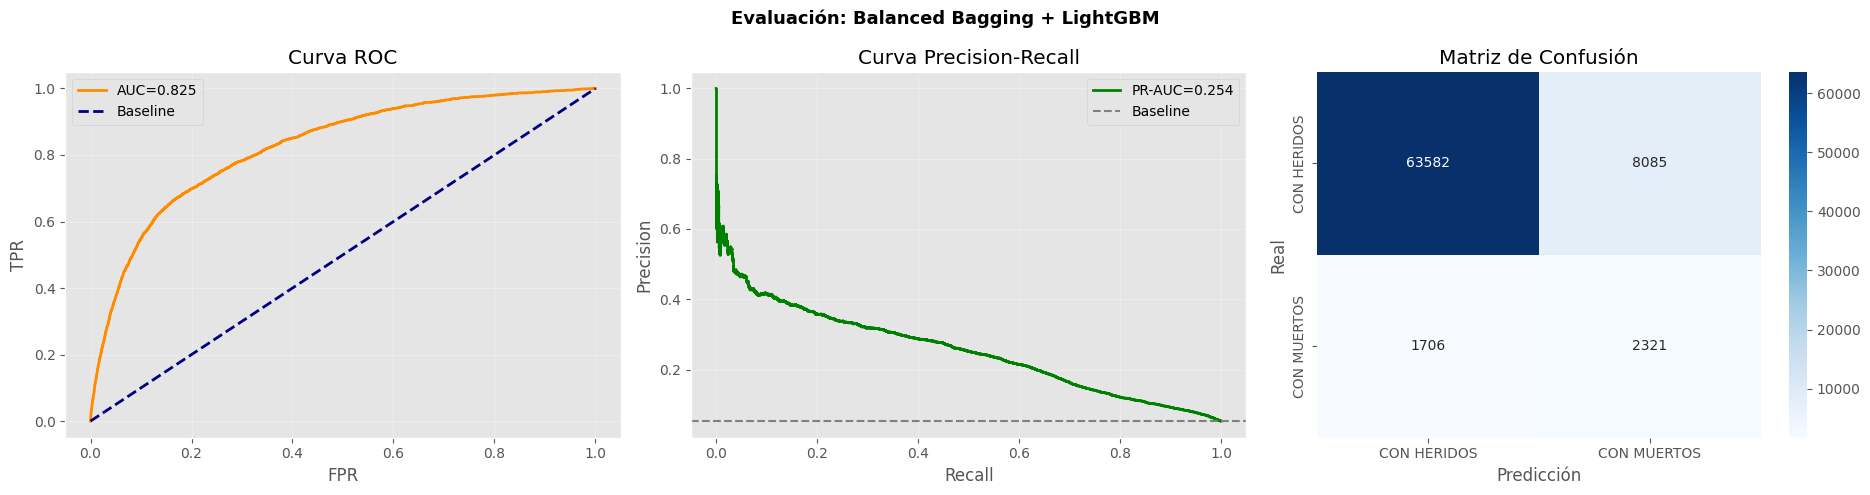

In [15]:
X_tr_sub_bb, _, y_tr_sub_bb, _ = train_test_split(
    X_train, y_train, test_size=0.40, random_state=RANDOM_STATE, stratify=y_train
)
X_tr_cv_bb, X_val_bb, y_tr_cv_bb, y_val_bb = train_test_split(
    X_tr_sub_bb, y_tr_sub_bb, test_size=0.20,
    random_state=RANDOM_STATE, stratify=y_tr_sub_bb
)

lgbm_base_bb = lgb.LGBMClassifier(
    random_state=RANDOM_STATE, device='gpu', verbose=-1, n_jobs=1
)
pipe_bb = ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', BalancedBaggingClassifier(
        estimator=lgbm_base_bb, n_estimators=15,
        sampling_strategy='auto', replacement=False,
        random_state=RANDOM_STATE, n_jobs=1
    ))
])

rs_bb = RandomizedSearchCV(
    pipe_bb,
    {'model__n_estimators': [15, 30, 50], 'model__sampling_strategy': ['auto', 0.5, 0.75],
     'model__replacement': [True, False], 'model__estimator__max_depth': [3, 5, 7],
     'model__estimator__num_leaves': [31, 63], 'model__estimator__subsample': [0.8, 0.9]},
    n_iter=15, cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
    scoring=make_scorer(f1_score, average='macro'), n_jobs=1,
    random_state=RANDOM_STATE, verbose=1, refit=True
)
rs_bb.fit(X_tr_cv_bb, y_tr_cv_bb)
print(f'Mejores params: {rs_bb.best_params_}')
print(f'F1-Macro (CV):  {rs_bb.best_score_:.4f}')

result_bb = evaluate_model(
    rs_bb.best_estimator_, X_tr_cv_bb, X_test, y_tr_cv_bb, y_test,
    model_name='Balanced Bagging + LightGBM', cv_folds=0, make_plots=True, refit=False
)
results.append(result_bb)

### 9.7 Isolation Forest (Detección de Anomalías) <a id='9.7'></a>

Paradigma: accidentes CON MUERTOS (~5%) son "anomalías" — combinaciones de features físicas raras que el bosque aísla con menos cortes.

F1-Macro:  0.5894  ← PRINCIPAL
ROC-AUC:   0.7432
PR-AUC:    0.1548
MCC:       0.2081
Umbral:    0.3859

              precision    recall  f1-score   support

 CON HERIDOS       0.96      0.90      0.93     71667
 CON MUERTOS       0.18      0.40      0.25      4027

    accuracy                           0.87     75694
   macro avg       0.57      0.65      0.59     75694
weighted avg       0.92      0.87      0.89     75694



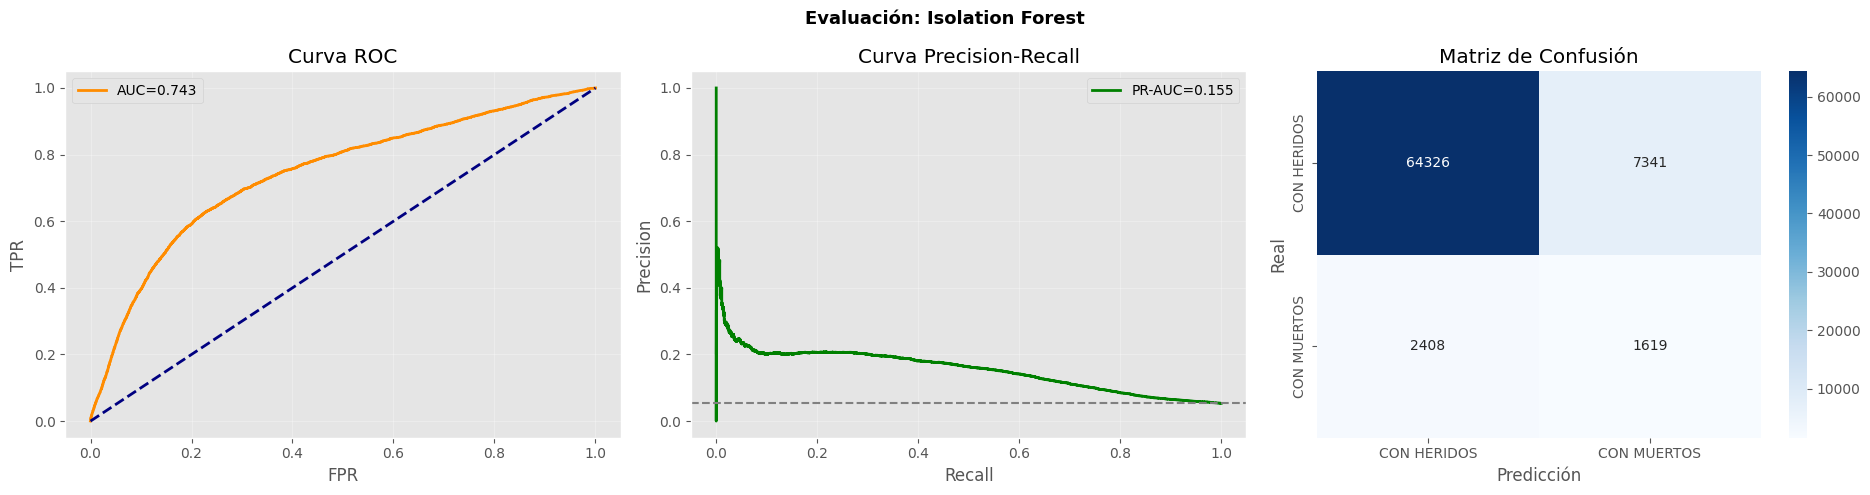

✓ Isolation Forest agregado. Total modelos: 7


In [16]:
preprocessor.fit(X_train, y_train)
X_train_proc = preprocessor.transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# Entrenar SOLO sobre clase normal (HERIDOS) para definir la frontera de normalidad
X_train_normal = X_train_proc[y_train.values == 0]
tasa_positivos = y_train.mean()

iso_forest = IsolationForest(
    n_estimators=300, contamination=tasa_positivos,
    max_samples='auto', random_state=RANDOM_STATE, n_jobs=-1
)
iso_forest.fit(X_train_normal)

# Score de anomalía: más negativo = más anómalo → invertir y normalizar a [0,1]
scaler_iso       = MinMaxScaler()
score_train_norm = scaler_iso.fit_transform(-iso_forest.decision_function(X_train_proc).reshape(-1,1)).ravel()
score_test_norm  = scaler_iso.transform(-iso_forest.decision_function(X_test_proc).reshape(-1,1)).ravel()

# Threshold tuning sobre subconjunto de validación interna
_, X_val_iso, _, y_val_iso, _, score_val_iso = train_test_split(
    X_train_proc, y_train, score_train_norm,
    test_size=0.20, random_state=RANDOM_STATE, stratify=y_train
)
prec_iso, rec_iso, thr_iso = precision_recall_curve(y_val_iso, score_val_iso)
f1s_iso   = 2*(prec_iso[:-1]*rec_iso[:-1])/(prec_iso[:-1]+rec_iso[:-1]+1e-9)
best_thr_iso = thr_iso[np.argmax(f1s_iso)]

y_pred_iso = (score_test_norm >= best_thr_iso).astype(int)
f1_mac_iso = f1_score(y_test, y_pred_iso, average='macro')
auc_iso    = roc_auc_score(y_test, score_test_norm)
aucpr_iso  = average_precision_score(y_test, score_test_norm)
mcc_iso    = matthews_corrcoef(y_test, y_pred_iso)

print(f'F1-Macro:  {f1_mac_iso:.4f}  ← PRINCIPAL')
print(f'ROC-AUC:   {auc_iso:.4f}')
print(f'PR-AUC:    {aucpr_iso:.4f}')
print(f'MCC:       {mcc_iso:.4f}')
print(f'Umbral:    {best_thr_iso:.4f}')
print()
print(classification_report(y_test, y_pred_iso, target_names=class_names))

# Gráficas estándar (mismas 3 que el resto)
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
fig.suptitle('Evaluación: Isolation Forest', fontsize=13, fontweight='bold')
fpr_i, tpr_i, _ = roc_curve(y_test, score_test_norm)
axes[0].plot(fpr_i, tpr_i, 'darkorange', lw=2, label=f'AUC={auc_iso:.3f}')
axes[0].plot([0,1],[0,1],'navy',lw=2,linestyle='--'); axes[0].set_title('Curva ROC')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend(); axes[0].grid(alpha=0.3)
prec_c_i, rec_c_i, _ = precision_recall_curve(y_test, score_test_norm)
axes[1].plot(rec_c_i, prec_c_i, 'green', lw=2, label=f'PR-AUC={aucpr_iso:.3f}')
axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--')
axes[1].set_title('Curva Precision-Recall'); axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision'); axes[1].legend(); axes[1].grid(alpha=0.3)
cm_iso = confusion_matrix(y_test, y_pred_iso)
sns.heatmap(cm_iso, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=class_names, yticklabels=class_names)
axes[2].set_title('Matriz de Confusión')
axes[2].set_xlabel('Predicción'); axes[2].set_ylabel('Real')
plt.tight_layout(); plt.show()

# Acumular en results con mismo formato
results.append({
    'model': 'Isolation Forest', 'accuracy': accuracy_score(y_test, y_pred_iso),
    'f1_macro': f1_mac_iso, 'f1_weighted': f1_score(y_test, y_pred_iso, average='weighted'),
    'f1_muertos': f1_score(y_test, y_pred_iso, pos_label=1),
    'recall_muertos': recall_score(y_test, y_pred_iso, pos_label=1),
    'precision_macro': precision_score(y_test, y_pred_iso, average='macro', zero_division=0),
    'recall_macro': recall_score(y_test, y_pred_iso, average='macro'),
    'mcc': mcc_iso, 'auc': auc_iso, 'pr_auc': aucpr_iso,
    'train_time': 0.0, 'predictions': y_pred_iso,
    'probabilities': np.column_stack([1-score_test_norm, score_test_norm]),
    'f1': f1_mac_iso, 'precision': precision_score(y_test, y_pred_iso, average='macro', zero_division=0),
    'recall': recall_score(y_test, y_pred_iso, average='macro'),
})
print(f'✓ Isolation Forest agregado. Total modelos: {len(results)}')

### 9.8 RUSBoost <a id='9.8'></a>

Random Under-Sampling integrado dentro de cada iteración de boosting — diseñado específicamente para imbalance extremo.

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Mejores params: {'model__sampling_strategy': 'auto', 'model__replacement': False, 'model__n_estimators': 300, 'model__learning_rate': 0.05, 'model__estimator__min_samples_leaf': 50, 'model__estimator__max_depth': 1}
F1-Macro (CV submuestra): 0.5970

TEST SET — RUSBoost
   F1-Macro:          0.5847  ← PRINCIPAL
   F1-MUERTOS:        0.2778
   Recall-MUERTOS:    0.6812
   Precision-MUERTOS: 0.1745
   Accuracy:          0.8116
   MCC:               0.2767
   ROC-AUC:           0.8246
   PR-AUC:            0.2430
   Tiempo:            0.00s

              precision    recall  f1-score   support

 CON HERIDOS       0.98      0.82      0.89     71667
 CON MUERTOS       0.17      0.68      0.28      4027

    accuracy                           0.81     75694
   macro avg       0.58      0.75      0.58     75694
weighted avg       0.94      0.81      0.86     75694



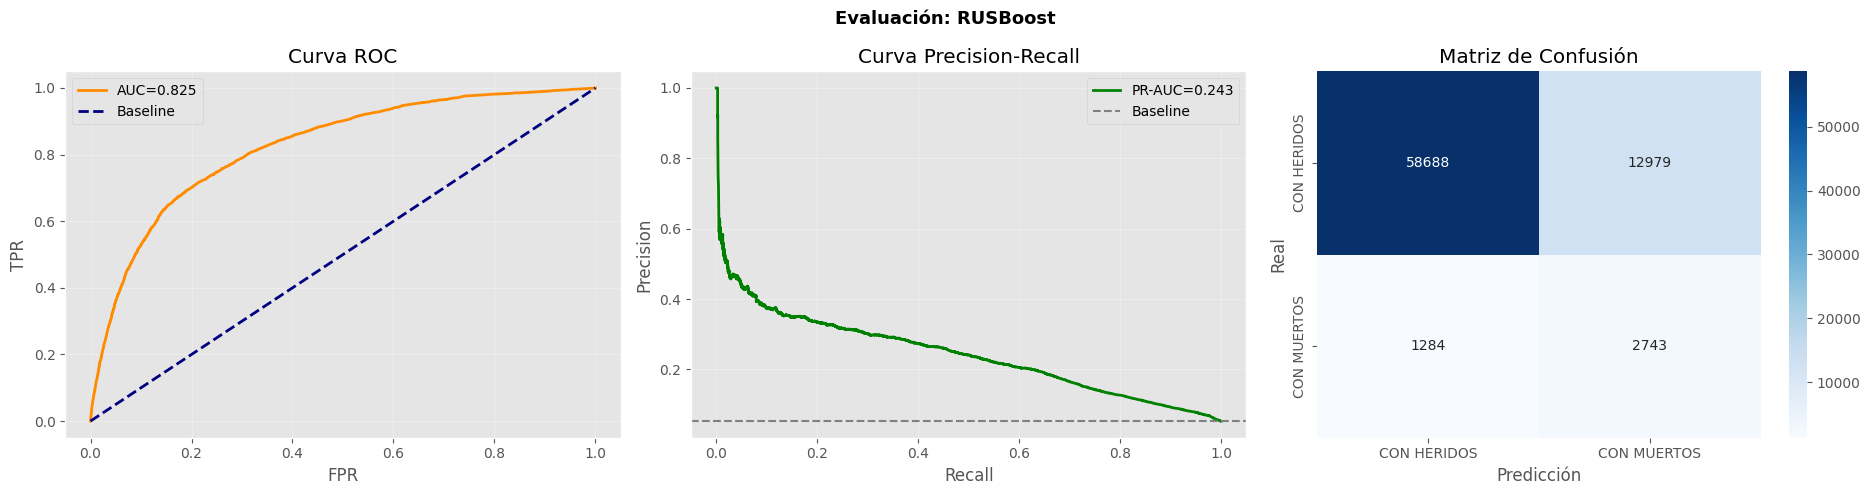

In [17]:
X_tr_rus, X_val_rus, y_tr_rus, y_val_rus = train_test_split(
    X_train, y_train, test_size=0.20, random_state=RANDOM_STATE, stratify=y_train
)

# Submuestra 15% para búsqueda eficiente con 400k
X_search_rus, _, y_search_rus, _ = train_test_split(
    X_tr_rus, y_tr_rus, test_size=0.85, random_state=RANDOM_STATE, stratify=y_tr_rus
)

pipe_rus = ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', RUSBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3, min_samples_leaf=50,
                                          class_weight='balanced', random_state=RANDOM_STATE),
        random_state=RANDOM_STATE
    ))
])

rs_rus = RandomizedSearchCV(
    pipe_rus,
    {'model__n_estimators': [100, 200, 300], 'model__learning_rate': [0.05, 0.1, 0.2],
     'model__sampling_strategy': ['auto', 0.5, 0.3], 'model__replacement': [True, False],
     'model__estimator__max_depth': [1, 2, 3, 5], 'model__estimator__min_samples_leaf': [20, 50, 100]},
    n_iter=20, cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
    scoring=make_scorer(f1_score, average='macro'), n_jobs=-1,
    random_state=RANDOM_STATE, verbose=1, refit=False
)
rs_rus.fit(X_search_rus, y_search_rus)
print(f'Mejores params: {rs_rus.best_params_}')
print(f'F1-Macro (CV submuestra): {rs_rus.best_score_:.4f}')

pipe_rus.set_params(**rs_rus.best_params_)
pipe_rus.fit(X_tr_rus, y_tr_rus)

result_rus = evaluate_model(
    pipe_rus, X_tr_rus, X_test, y_tr_rus, y_test,
    model_name='RUSBoost', cv_folds=0, make_plots=True, refit=False
)
results.append(result_rus)

### 9.9 IMBoost <a id='9.9'></a>

Implementación del paper Roshan (2023): AdaBoost con factores de ponderación diferenciados por clase (α_min y α_maj independientes).

In [18]:
class IMBoost(BaseEstimator, ClassifierMixin):
    """
    IMBoost: AdaBoost con alpha diferenciado por clase.
    Ref: Roshan (2023), Complexity Journal, doi:10.1155/2023/2176891
    """
    def __init__(self, n_estimators=100, max_depth=5, random_state=42):
        self.n_estimators = n_estimators
        self.max_depth    = max_depth
        self.random_state = random_state

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        if hasattr(X, 'values'): X = X.values
        if hasattr(y, 'values'): y = y.values
        np.random.seed(self.random_state)
        self.classes_ = np.unique(y)
        y_t     = np.where(y == 1, 1, -1)
        n       = len(y)
        min_idx = np.where(y == 1)[0]
        maj_idx = np.where(y == 0)[0]
        w = np.zeros(n)
        w[min_idx] = 1.0 / len(min_idx)
        w[maj_idx] = 1.0 / len(maj_idx)
        self.classifiers_, self.alphas_min_, self.alphas_maj_ = [], [], []
        for t in range(self.n_estimators):
            try:
                idx = np.random.choice(n, size=n, replace=True, p=w/w.sum())
                clf = DecisionTreeClassifier(max_depth=self.max_depth,
                                              random_state=self.random_state+t)
                clf.fit(X[idx], y_t[idx])
                pred     = clf.predict(X)
                min_mask = (y_t ==  1)
                maj_mask = (y_t == -1)
                def werr(mask):
                    err = np.sum(w[mask] * (pred[mask] != y_t[mask]))
                    tot = w[mask].sum()
                    return np.clip(err/tot if tot>0 else 0.5, 1e-10, 1-1e-10)
                a_min = 0.5 * np.log((1 - werr(min_mask)) / werr(min_mask))
                a_maj = 0.5 * np.log((1 - werr(maj_mask)) / werr(maj_mask))
                w[min_mask] *= np.exp(-a_min * y_t[min_mask] * pred[min_mask])
                w[maj_mask] *= np.exp(-a_maj * y_t[maj_mask] * pred[maj_mask])
                w /= w.sum()
                self.classifiers_.append(clf)
                self.alphas_min_.append(a_min)
                self.alphas_maj_.append(a_maj)
            except Exception as e:
                warnings.warn(f'IMBoost iter {t}: {e}')
        self.n_features_in_ = X.shape[1]
        return self

    def _score(self, X):
        X = check_array(X)
        if hasattr(X,'values'): X = X.values
        s = np.zeros(X.shape[0])
        for a_min, a_maj, clf in zip(self.alphas_min_, self.alphas_maj_, self.classifiers_):
            s += (a_min + a_maj) * clf.predict(X)
        return s

    def predict(self, X):
        return np.where(self._score(X) >= 0, 1, 0)

    def predict_proba(self, X):
        p = np.clip(1 / (1 + np.exp(-self._score(X))), 0, 1)
        return np.vstack([1-p, p]).T

print('✓ IMBoost definido')

✓ IMBoost definido


Best trial: 3. Best value: 0.545868: 100%|██████████| 20/20 [06:26<00:00, 19.31s/it]


F1-Macro:  0.5236  ← PRINCIPAL
ROC-AUC:   0.7456
PR-AUC:    0.1622
MCC:       0.1810

              precision    recall  f1-score   support

 CON HERIDOS       0.97      0.75      0.85     71667
 CON MUERTOS       0.12      0.61      0.20      4027

    accuracy                           0.74     75694
   macro avg       0.55      0.68      0.52     75694
weighted avg       0.93      0.74      0.81     75694



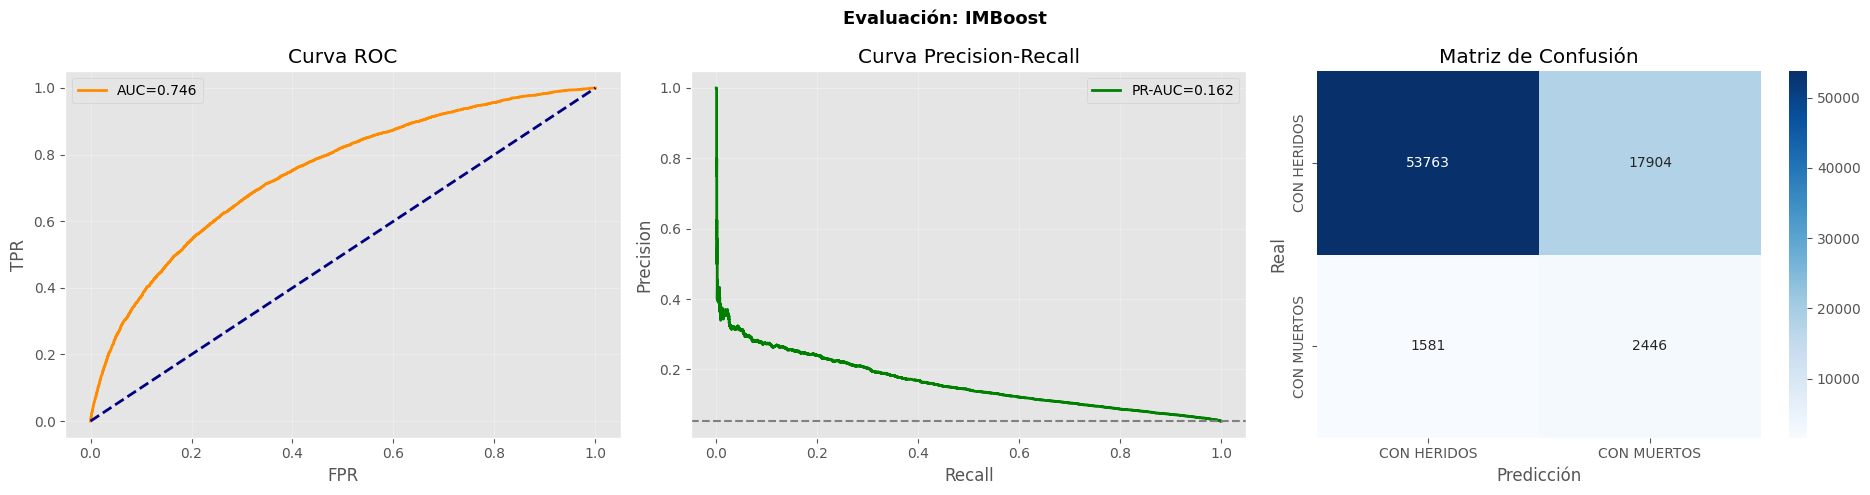

✓ IMBoost agregado. Total modelos: 9


In [19]:
# Submuestra 50% estratificada para Optuna
X_sub_imb, _, y_sub_imb, _ = train_test_split(
    X_train, y_train, test_size=0.50, random_state=RANDOM_STATE, stratify=y_train
)
X_tr_imb, X_val_imb, y_tr_imb, y_val_imb = train_test_split(
    X_sub_imb, y_sub_imb, test_size=0.20, random_state=RANDOM_STATE, stratify=y_sub_imb
)

preprocessor.fit(X_tr_imb, y_tr_imb)
X_tr_imb_proc  = preprocessor.transform(X_tr_imb)
X_val_imb_proc = preprocessor.transform(X_val_imb)
X_test_imb_proc = preprocessor.transform(X_test)

def objective_imb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=50),
        'max_depth':    trial.suggest_int('max_depth', 2, 7),
    }
    clf = IMBoost(**params, random_state=RANDOM_STATE)
    cv  = StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(clf, X_tr_imb_proc, y_tr_imb, cv=cv,
                            scoring=make_scorer(f1_score, average='macro'), n_jobs=-1)
    return scores['test_score'].mean()

study_imb = optuna.create_study(direction='maximize',
                                 sampler=TPESampler(seed=RANDOM_STATE))
study_imb.optimize(objective_imb, n_trials=20, show_progress_bar=True)

best_imb = IMBoost(**study_imb.best_params, random_state=RANDOM_STATE)
best_imb.fit(X_tr_imb_proc, y_tr_imb)

y_pred_imb   = best_imb.predict(X_test_imb_proc)
y_proba_imb  = best_imb.predict_proba(X_test_imb_proc)[:, 1]
f1_mac_imb   = f1_score(y_test, y_pred_imb, average='macro')
auc_imb      = roc_auc_score(y_test, y_proba_imb)
aucpr_imb    = average_precision_score(y_test, y_proba_imb)
mcc_imb      = matthews_corrcoef(y_test, y_pred_imb)

print(f'F1-Macro:  {f1_mac_imb:.4f}  ← PRINCIPAL')
print(f'ROC-AUC:   {auc_imb:.4f}')
print(f'PR-AUC:    {aucpr_imb:.4f}')
print(f'MCC:       {mcc_imb:.4f}')
print()
print(classification_report(y_test, y_pred_imb, target_names=class_names))

# Gráficas estándar
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
fig.suptitle('Evaluación: IMBoost', fontsize=13, fontweight='bold')
fpr_im, tpr_im, _ = roc_curve(y_test, y_proba_imb)
axes[0].plot(fpr_im, tpr_im, 'darkorange', lw=2, label=f'AUC={auc_imb:.3f}')
axes[0].plot([0,1],[0,1],'navy',lw=2,linestyle='--'); axes[0].set_title('Curva ROC')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend(); axes[0].grid(alpha=0.3)
prec_im, rec_im, _ = precision_recall_curve(y_test, y_proba_imb)
axes[1].plot(rec_im, prec_im, 'green', lw=2, label=f'PR-AUC={aucpr_imb:.3f}')
axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--')
axes[1].set_title('Curva Precision-Recall'); axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision'); axes[1].legend(); axes[1].grid(alpha=0.3)
cm_im = confusion_matrix(y_test, y_pred_imb)
sns.heatmap(cm_im, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=class_names, yticklabels=class_names)
axes[2].set_title('Matriz de Confusión')
axes[2].set_xlabel('Predicción'); axes[2].set_ylabel('Real')
plt.tight_layout(); plt.show()

results.append({
    'model': 'IMBoost', 'accuracy': accuracy_score(y_test, y_pred_imb),
    'f1_macro': f1_mac_imb, 'f1_weighted': f1_score(y_test, y_pred_imb, average='weighted'),
    'f1_muertos': f1_score(y_test, y_pred_imb, pos_label=1),
    'recall_muertos': recall_score(y_test, y_pred_imb, pos_label=1),
    'precision_macro': precision_score(y_test, y_pred_imb, average='macro', zero_division=0),
    'recall_macro': recall_score(y_test, y_pred_imb, average='macro'),
    'mcc': mcc_imb, 'auc': auc_imb, 'pr_auc': aucpr_imb,
    'train_time': 0.0, 'predictions': y_pred_imb,
    'probabilities': np.column_stack([1-y_proba_imb, y_proba_imb]),
    'f1': f1_mac_imb, 'precision': precision_score(y_test, y_pred_imb, average='macro', zero_division=0),
    'recall': recall_score(y_test, y_pred_imb, average='macro'),
})
print(f'✓ IMBoost agregado. Total modelos: {len(results)}')

## 10. Ranking Final de Modelos <a id='10'></a>

Tabla comparativa ordenada por **F1-Macro** (métrica principal) con colores para identificar el mejor modelo.

In [25]:
# ── Construir DataFrame ──────────────────────────────────────────────────────
results_df = pd.DataFrame([{
    'Modelo':        r.get('model',            '—'),
    'F1-Macro ↑':   round(r.get('f1_macro',         0) or 0, 4),
    'F1-MUERTOS':   round(r.get('f1_muertos',        0) or 0, 4),
    'Recall-MUE':   round(r.get('recall_muertos',    0) or 0, 4),
    'Accuracy':     round(r.get('accuracy',          0) or 0, 4),
    'MCC':          round(r.get('mcc',               0) or 0, 4),
    'ROC-AUC':      round(r.get('auc',               0) or 0, 4),
    'PR-AUC':       round(r.get('pr_auc',            0) or 0, 4),
} for r in results]).sort_values('F1-Macro ↑', ascending=False).reset_index(drop=True)

results_df.insert(0, 'Rank', range(1, len(results_df) + 1))

print('RANKING FINAL DE MODELOS')
print('=' * 100)
print(results_df.to_string(index=False))
print()
print(f'🥇 Mejor modelo: {results_df.iloc[0]["Modelo"]}  (F1-Macro: {results_df.iloc[0]["F1-Macro ↑"]:.4f})')

RANKING FINAL DE MODELOS
 Rank                      Modelo  F1-Macro ↑  F1-MUERTOS  Recall-MUE  Accuracy    MCC  ROC-AUC  PR-AUC
    1      Balanced Random Forest      0.6405      0.3365      0.4889    0.8974 0.3043   0.8269  0.2490
    2                     XGBoost      0.6262      0.3235      0.5783    0.8713 0.3042   0.8251  0.2600
    3 Balanced Bagging + LightGBM      0.6251      0.3216      0.5764    0.8707 0.3021   0.8250  0.2539
    4               Random Forest      0.6244      0.2980      0.3673    0.9079 0.2559   0.7894  0.2110
    5         Logistic Regression      0.5961      0.2903      0.6633    0.8275 0.2861   0.8190  0.2410
    6            Isolation Forest      0.5894      0.2493      0.4020    0.8712 0.2081   0.7432  0.1548
    7                    RUSBoost      0.5847      0.2778      0.6812    0.8116 0.2767   0.8246  0.2430
    8            LightGBM + SMOTE      0.5518      0.1321      0.0790    0.9448 0.1600   0.8034  0.2287
    9                     IMBoost      

In [26]:
# ── Tabla con colores (verde = mejor, rojo = peor) por columna ───────────────
def color_rank(df):
    """
    Aplica gradiente de color a cada columna numérica.
    Verde = mejor valor, Rojo = peor valor.
    Fondo dorado para la fila del mejor modelo (Rank 1).
    """
    styled = df.copy()
    cols_asc = ['F1-Macro ↑', 'F1-MUERTOS', 'Recall-MUE',
                'Accuracy', 'MCC', 'ROC-AUC', 'PR-AUC', 'CV-F1-Macro']

    def apply_gradient(col):
        mn, mx = col.min(), col.max()
        if mx == mn:
            return ['background-color: #f5f5f5'] * len(col)
        styles = []
        for v in col:
            if pd.isna(v) or v == 0:
                styles.append('background-color: #f5f5f5; color: #aaa')
                continue
            t = (v - mn) / (mx - mn)  # 0=peor, 1=mejor
            r = int(255 * (1 - t))
            g = int(200 * t)
            b = int(80  * t)
            brightness = 0.299*r + 0.587*g + 0.114*b
            txt = 'black' if brightness > 140 else 'white'
            styles.append(f'background-color: rgb({r},{g},{b}); color: {txt}; font-weight: 500')
        return styles

    style = df.style

    for col in cols_asc:
        if col in df.columns:
            style = style.apply(apply_gradient, subset=[col])

    # Fondo dorado para la fila del mejor modelo
    def highlight_best(row):
        if row['Rank'] == 1:
            return ['background-color: #fff3cd; font-weight: bold; border: 2px solid #ffc107'] * len(row)
        return [''] * len(row)

    style = style.apply(highlight_best, axis=1)
    style = style.set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#2c3e50'), ('color', 'white'),
            ('font-weight', 'bold'), ('text-align', 'center'),
            ('padding', '8px 12px'), ('font-size', '12px')
        ]},
        {'selector': 'td', 'props': [
            ('text-align', 'center'), ('padding', '6px 10px'), ('font-size', '12px')
        ]},
        {'selector': '', 'props': [
            ('border-collapse', 'collapse'), ('width', '100%')
        ]},
    ])
    return style

display(color_rank(results_df))

,Rank,Modelo,F1-Macro ↑,F1-MUERTOS,Recall-MUE,Accuracy,MCC,ROC-AUC,PR-AUC
0,1,Balanced Random Forest,0.640500,0.336500,0.488900,0.897400,0.304300,0.826900,0.249000
1,2,XGBoost,0.626200,0.323500,0.578300,0.871300,0.304200,0.825100,0.260000
2,3,Balanced Bagging + LightGBM,0.625100,0.321600,0.576400,0.870700,0.302100,0.825000,0.253900
3,4,Random Forest,0.624400,0.298000,0.367300,0.907900,0.255900,0.789400,0.211000
4,5,Logistic Regression,0.596100,0.290300,0.663300,0.827500,0.286100,0.819000,0.241000
5,6,Isolation Forest,0.589400,0.249300,0.402000,0.871200,0.208100,0.743200,0.154800
6,7,RUSBoost,0.584700,0.277800,0.681200,0.811600,0.276700,0.824600,0.243000
7,8,LightGBM + SMOTE,0.551800,0.132100,0.079000,0.944800,0.160000,0.803400,0.228700
8,9,IMBoost,0.523600,0.200700,0.607400,0.742600,0.181000,0.745600,0.162200


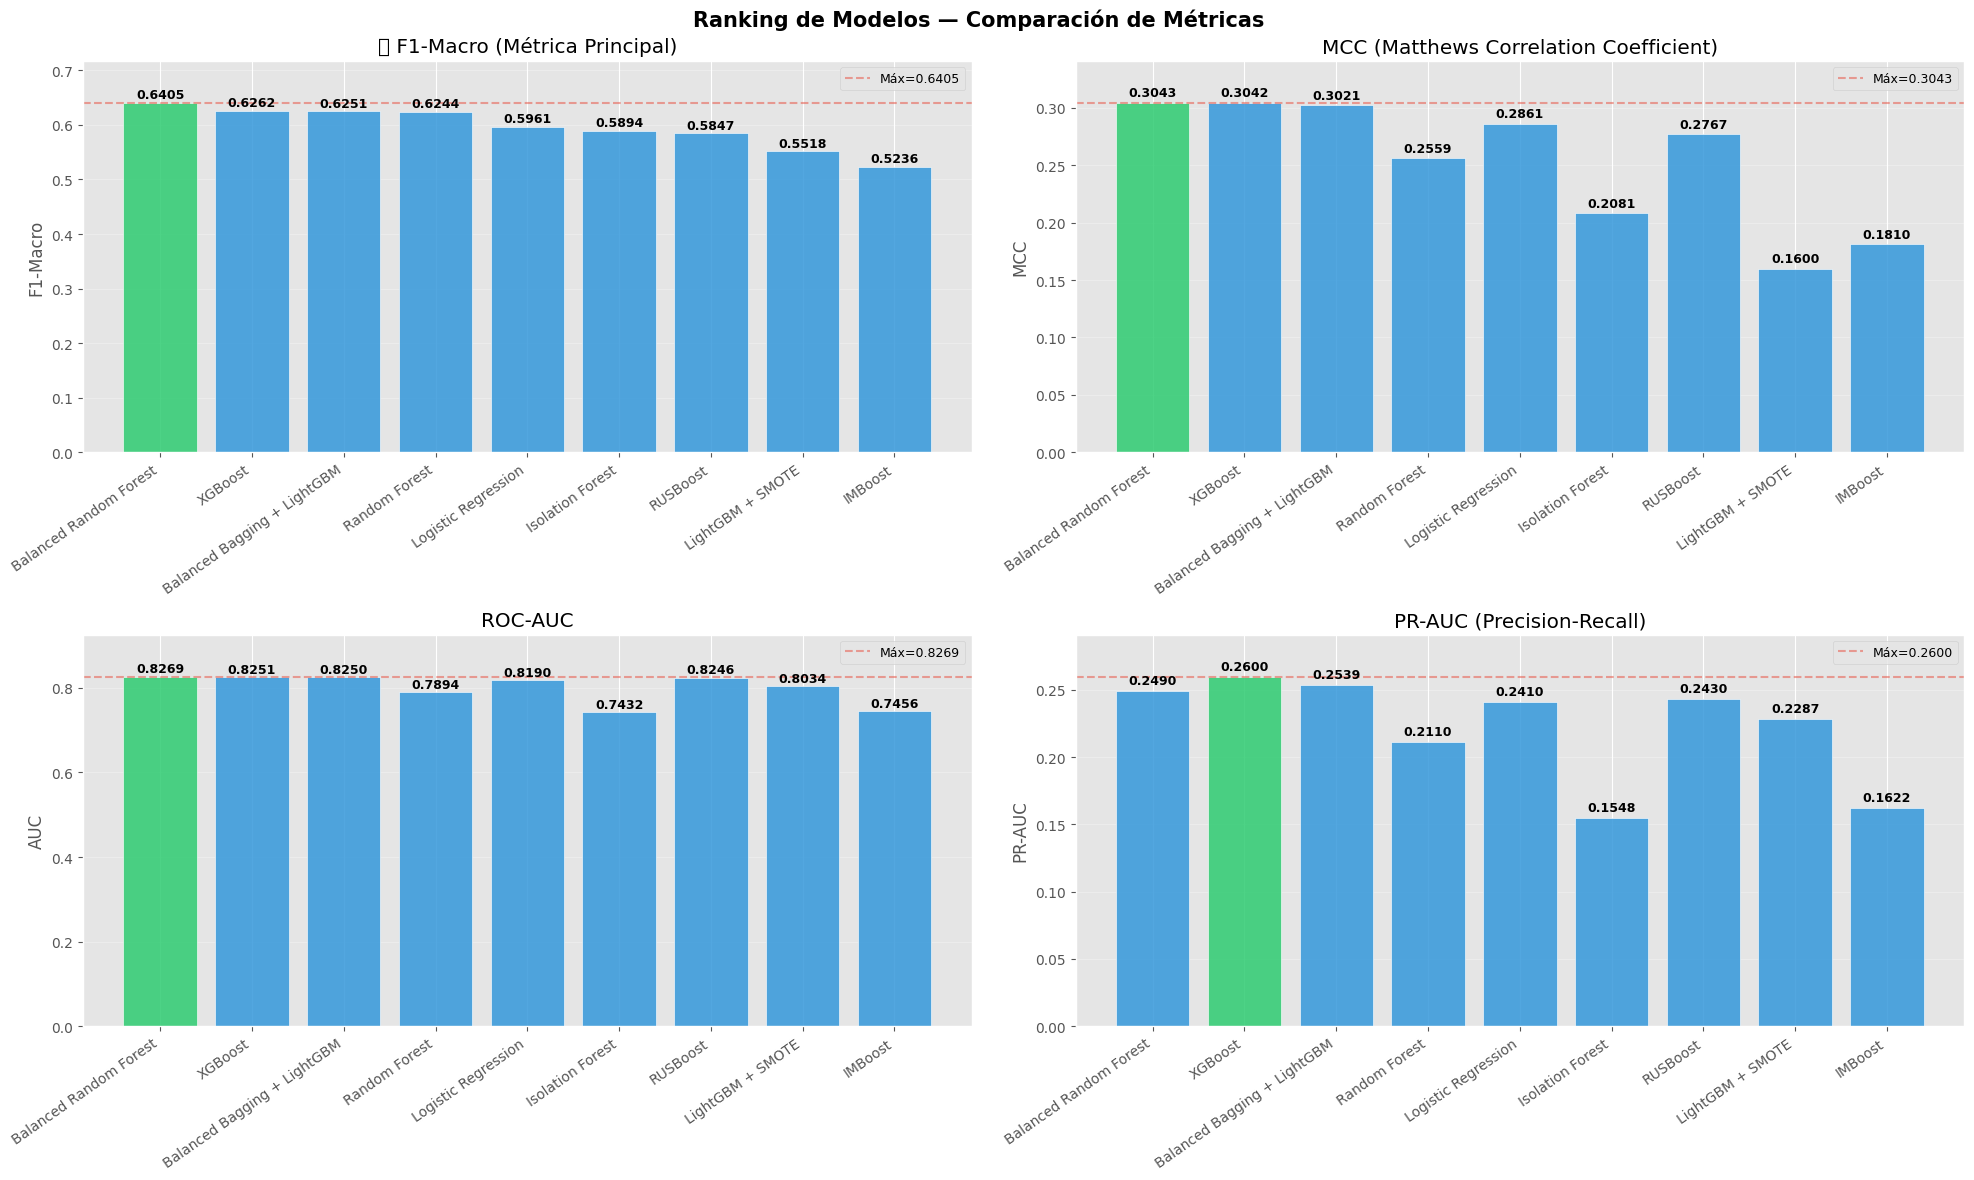

✓ Gráfico guardado como ranking_modelos.png


In [27]:
# ── Gráfico de barras comparativo ────────────────────────────────────────────
modelos  = results_df['Modelo'].tolist()
f1_vals  = results_df['F1-Macro ↑'].tolist()
mcc_vals = results_df['MCC'].tolist()
auc_vals = results_df['ROC-AUC'].tolist()
pr_vals  = results_df['PR-AUC'].tolist()

x     = np.arange(len(modelos))
width = 0.2
colores = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(modelos))]

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Ranking de Modelos — Comparación de Métricas', fontsize=15, fontweight='bold')

def barplot(ax, vals, title, ylabel, highlight_idx=0):
    bars = ax.bar(x, vals, color=['#2ecc71' if i==highlight_idx else '#3498db'
                                   for i in range(len(modelos))], alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(modelos, rotation=35, ha='right', fontsize=10)
    ax.set_ylabel(ylabel); ax.set_title(title)
    ax.set_ylim(0, max(vals)*1.12 if max(vals) > 0 else 1)
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=max(vals), color='#e74c3c', linestyle='--', alpha=0.5, label=f'Máx={max(vals):.4f}')
    ax.legend(fontsize=9)

barplot(axes[0,0], f1_vals,  '🏆 F1-Macro (Métrica Principal)', 'F1-Macro')
barplot(axes[0,1], mcc_vals, 'MCC (Matthews Correlation Coefficient)', 'MCC',
        highlight_idx=results_df['MCC'].values.argmax())
barplot(axes[1,0], auc_vals, 'ROC-AUC', 'AUC',
        highlight_idx=results_df['ROC-AUC'].values.argmax())
barplot(axes[1,1], pr_vals,  'PR-AUC (Precision-Recall)',  'PR-AUC',
        highlight_idx=results_df['PR-AUC'].values.argmax())

plt.tight_layout()
plt.savefig('ranking_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Gráfico guardado como ranking_modelos.png')

In [29]:
# ── Tabla de posiciones finales ───────────────────────────────────────────────
print()
print('=' * 65)
print(' RANKING FINAL — PREDICCIÓN GRAVEDAD ACCIDENTES COLOMBIA')
print('=' * 65)
print(f" {'Pos':>3}  {'Modelo':<38} {'F1-Macro':>9} {'MCC':>7} {'ROC-AUC':>9}")
print('-' * 65)

medallas = {1: '', 2: '', 3: ''}
for _, row in results_df.iterrows():
    medal = medallas.get(int(row['Rank']), '  ')
    print(f" {medal} #{int(row['Rank']):<2} {row['Modelo']:<38} {row['F1-Macro ↑']:>9.4f} {row['MCC']:>7.4f} {row['ROC-AUC']:>9.4f}")

print('=' * 65)
best = results_df.iloc[0]
print(f"\n Ganador: {best['Modelo']}")
print(f"   F1-Macro:  {best['F1-Macro ↑']:.4f}")
print(f"   MCC:       {best['MCC']:.4f}")
print(f"   ROC-AUC:   {best['ROC-AUC']:.4f}")
print(f"   PR-AUC:    {best['PR-AUC']:.4f}")
print(f"   F1-MUERTOS:{best['F1-MUERTOS']:.4f}")


 RANKING FINAL — PREDICCIÓN GRAVEDAD ACCIDENTES COLOMBIA
 Pos  Modelo                                  F1-Macro     MCC   ROC-AUC
-----------------------------------------------------------------
  #1  Balanced Random Forest                    0.6405  0.3043    0.8269
  #2  XGBoost                                   0.6262  0.3042    0.8251
  #3  Balanced Bagging + LightGBM               0.6251  0.3021    0.8250
    #4  Random Forest                             0.6244  0.2559    0.7894
    #5  Logistic Regression                       0.5961  0.2861    0.8190
    #6  Isolation Forest                          0.5894  0.2081    0.7432
    #7  RUSBoost                                  0.5847  0.2767    0.8246
    #8  LightGBM + SMOTE                          0.5518  0.1600    0.8034
    #9  IMBoost                                   0.5236  0.1810    0.7456

 Ganador: Balanced Random Forest
   F1-Macro:  0.6405
   MCC:       0.3043
   ROC-AUC:   0.8269
   PR-AUC:    0.2490
   F1-MUERTOS:0.